In [1]:
!pip install wordcloud --no-cache-dir
!pip install squarify


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\mansi\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\mansi\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64

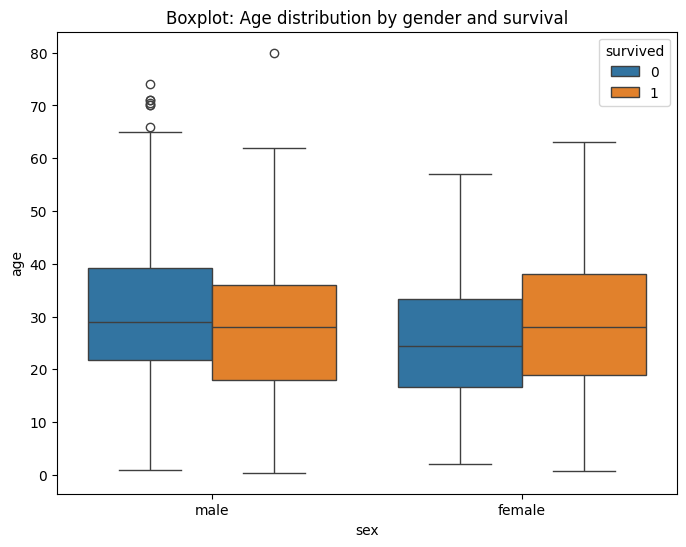

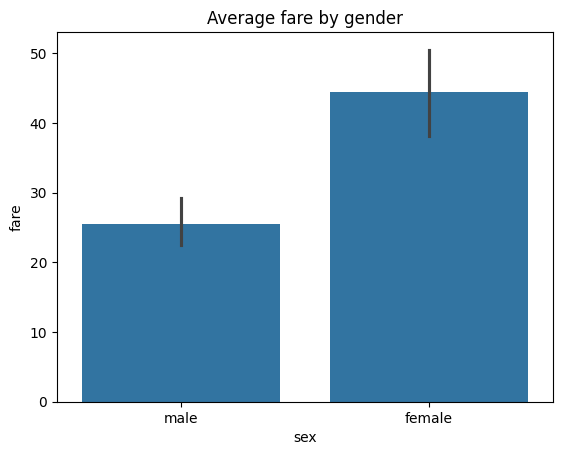

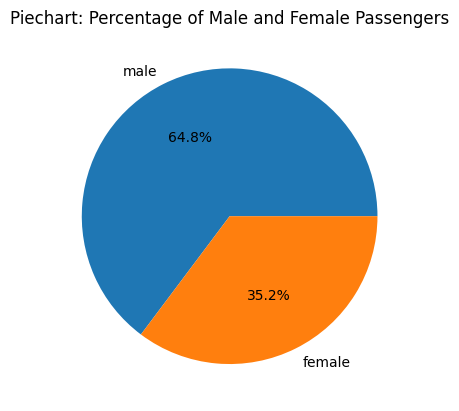

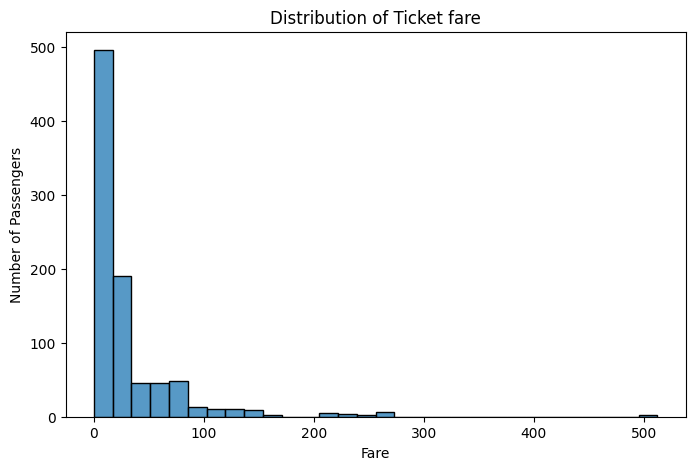

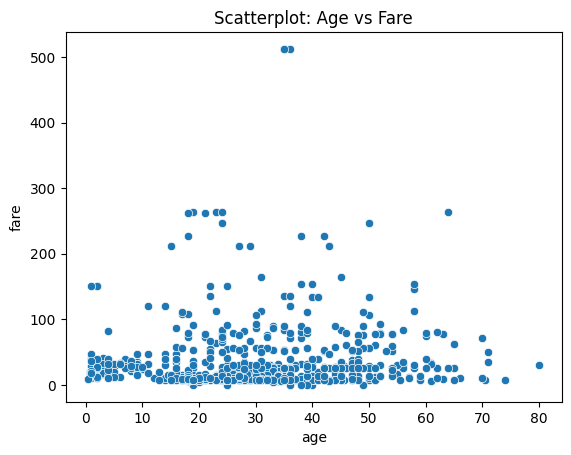

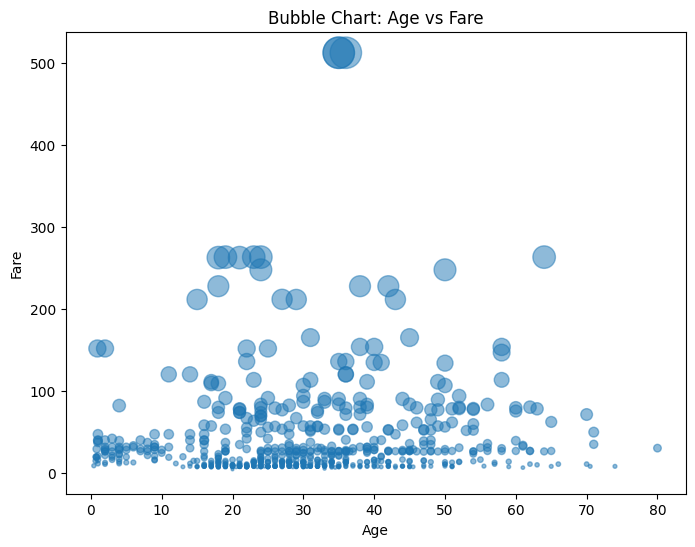

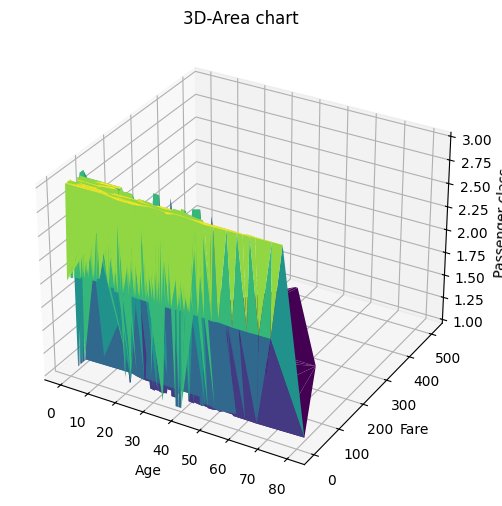

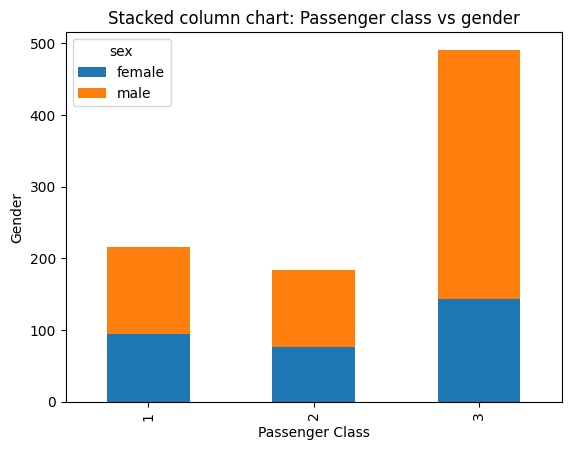

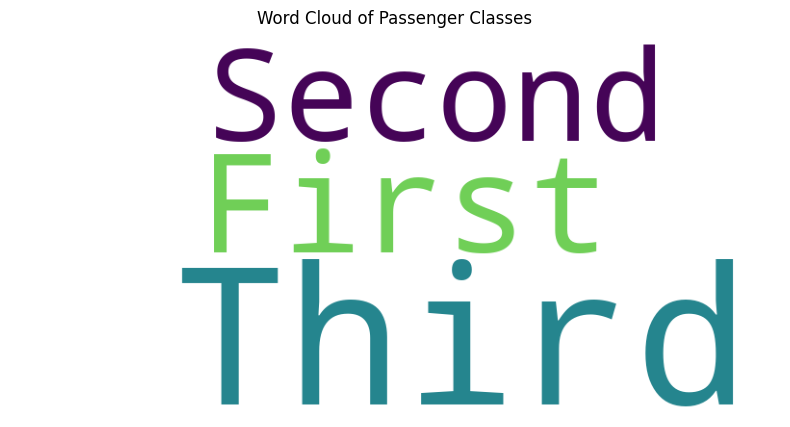

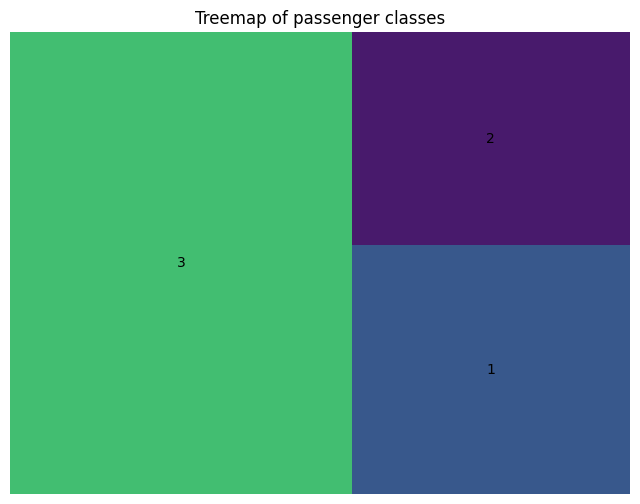

In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import squarify

titanic = sns.load_dataset("titanic")
print(titanic.head())
print(titanic.info())

plt.figure(figsize=(8,6))
sns.boxplot(x="sex", y="age", hue="survived", data=titanic)
plt.title("Boxplot: Age distribution by gender and survival")
plt.show()

sns.barplot(x="sex", y="fare", data=titanic)
plt.title("Average fare by gender")
plt.show()

titanic['sex'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Piechart: Percentage of Male and Female Passengers")
plt.ylabel("")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(titanic["fare"], bins=30)
plt.title("Distribution of Ticket fare")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()

sns.scatterplot(x="age", y="fare", data=titanic)
plt.title("Scatterplot: Age vs Fare")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(titanic["age"], titanic["fare"], s=titanic["fare"], alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Bubble Chart: Age vs Fare")
plt.show()

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
x = titanic["age"].fillna(0)
y = titanic["fare"]
z = titanic["pclass"]
ax.plot_trisurf(x, y, z, cmap="viridis")
ax.set_xlabel("Age")
ax.set_ylabel("Fare")
ax.set_zlabel("Passenger class")
plt.title("3D-Area chart")
plt.show()

data = titanic.groupby(["pclass","sex"]).size().unstack()
data.plot(kind="bar", stacked=True)
plt.title("Stacked column chart: Passenger class vs gender")
plt.xlabel("Passenger Class")
plt.ylabel("Gender")
plt.show()

text = " ".join(titanic["class"].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Passenger Classes")
plt.show()

sizes = titanic["pclass"].value_counts()
plt.figure(figsize=(8,6))
squarify.plot(sizes=sizes, label=sizes.index)
plt.title("Treemap of passenger classes")
plt.axis("off")
plt.show()